# Challenge 5 — Aero Alerts: Automated Weather Alerts for Airports


## 0. Configuration & setup

In [1]:
# In Colab Enterprise auth is automatic. Elsewhere:
# from google.colab import auth; auth.authenticate_user()

import requests, time, datetime
from google.cloud import bigquery, storage

PROJECT_ID = "qwiklabs-gcp-01-9ed82c2a1f67"   # change if different
DATASET    = "aero_alerts"
LOCATION   = "US"
CONNECTION = "vertex_conn"                     # BQ -> Vertex AI connection

# A Cloud Storage bucket to stage the CSV (must be globally unique).
BUCKET = f"{PROJECT_ID}-aero-alerts"

bq  = bigquery.Client(project=PROJECT_ID)
gcs = storage.Client(project=PROJECT_ID)

AIRPORTS_TABLE  = f"{PROJECT_ID}.{DATASET}.airports"
FORECAST_TABLE  = f"{PROJECT_ID}.{DATASET}.airport_forecasts"
ALERTS_TABLE    = f"{PROJECT_ID}.{DATASET}.airport_alerts"
GEMINI_MODEL    = f"{PROJECT_ID}.{DATASET}.gemini_model"

def run(sql):
    bq.query(sql).result()

bq.create_dataset(bigquery.Dataset(f"{PROJECT_ID}.{DATASET}"), exists_ok=True)
print("Dataset ready:", DATASET)


Dataset ready: aero_alerts


## 1. Download CSV → Cloud Storage → BigQuery
  

In [2]:
# Create the staging bucket if needed
try:
    bucket = gcs.create_bucket(BUCKET, location=LOCATION)
    print("Created bucket:", BUCKET)
except Exception as e:
    bucket = gcs.bucket(BUCKET)
    print("Using existing bucket:", BUCKET, "|", e)

# Stream the public CSV straight into our bucket (no local disk needed)
src = "https://storage.googleapis.com/labs.roitraining.com/data-to-ai-workshop/airports.csv"
blob = bucket.blob("airports.csv")
r = requests.get(src, timeout=120)
r.raise_for_status()
blob.upload_from_string(r.content, content_type="text/csv")
print(f"Uploaded airports.csv to gs://{BUCKET}/airports.csv ({len(r.content)/1e6:.1f} MB)")


Created bucket: qwiklabs-gcp-01-9ed82c2a1f67-aero-alerts
Uploaded airports.csv to gs://qwiklabs-gcp-01-9ed82c2a1f67-aero-alerts/airports.csv (12.3 MB)


In [3]:
run(f"""
LOAD DATA OVERWRITE `{AIRPORTS_TABLE}`
FROM FILES (
  format = 'CSV',
  uris   = ['gs://{BUCKET}/airports.csv'],
  skip_leading_rows = 1,
  field_delimiter = ',',
  quote = '"',
  max_bad_records = 50
)
""")
print("Loaded:", AIRPORTS_TABLE)


Loaded: qwiklabs-gcp-01-9ed82c2a1f67.aero_alerts.airports


## 2. Filter to US large airports

In [4]:
run(f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{DATASET}.large_airports_us` AS
SELECT
  ident, name, municipality, iso_region,
  iata_code, latitude_deg, longitude_deg
FROM `{AIRPORTS_TABLE}`
WHERE type = 'large_airport'
  AND iso_country = 'US'
  AND latitude_deg IS NOT NULL
  AND longitude_deg IS NOT NULL
""")

large = bq.query(f"SELECT * FROM `{PROJECT_ID}.{DATASET}.large_airports_us` ORDER BY name").to_dataframe()
print("US large airports:", len(large))
large.head(10)


US large airports: 71


,ident,name,municipality,iso_region,iata_code,latitude_deg,longitude_deg
0,KABQ,Albuquerque International Sunport,Albuquerque,US-NM,ABQ,35.039976,-106.608925
1,KAUS,Austin Bergstrom International Airport,Austin,US-TX,AUS,30.197535,-97.662015
2,KBWI,Baltimore/Washington International Thurgood Ma...,Baltimore,US-MD,BWI,39.175400,-76.668297
3,KBDL,Bradley International Airport,Hartford,US-CT,BDL,41.938510,-72.688066
4,KBUF,Buffalo Niagara International Airport,Buffalo,US-NY,BUF,42.940498,-78.732201
5,KCLT,Charlotte Douglas International Airport,Charlotte,US-NC,CLT,35.214001,-80.943100
6,KMDW,Chicago Midway International Airport,Chicago,US-IL,MDW,41.785999,-87.752403
7,KORD,Chicago O'Hare International Airport,Chicago,US-IL,ORD,41.978600,-87.904800
8,KCVG,Cincinnati Northern Kentucky International Air...,Cincinnati / Covington,US-KY,CVG,39.048801,-84.667801
9,KCLE,Cleveland Hopkins International Airport,Cleveland,US-OH,CLE,41.411701,-81.849800


## 3. Get forecasts from the National Weather Service API


In [5]:
NWS = "https://api.weather.gov"
HEADERS = {
    "User-Agent": "AeroAlerts-Workshop (student@example.com)",
    "Accept": "application/geo+json",
}

def get_forecast(lat, lon, retries=3):
    """Return (short_forecast_text, detailed_text) for a lat/lon, or (None, None)."""
    for attempt in range(retries):
        try:
            pts = requests.get(f"{NWS}/points/{lat:.4f},{lon:.4f}", headers=HEADERS, timeout=20)
            if pts.status_code != 200:
                time.sleep(1); continue
            forecast_url = pts.json()["properties"]["forecast"]

            fc = requests.get(forecast_url, headers=HEADERS, timeout=20)
            if fc.status_code != 200:
                time.sleep(1); continue
            periods = fc.json()["properties"]["periods"]
            if not periods:
                return (None, None)
            now = periods[0]
            short  = f"{now['name']}: {now['shortForecast']}, {now['temperature']}{now['temperatureUnit']}, wind {now['windSpeed']} {now['windDirection']}"
            detail = now.get("detailedForecast", "")
            return (short, detail)
        except Exception as e:
            time.sleep(1)
    return (None, None)

# Smoke test on the first airport
row0 = large.iloc[0]
print(row0["name"])
print(get_forecast(row0["latitude_deg"], row0["longitude_deg"]))


Albuquerque International Sunport
('Today: Partly Sunny then Chance Showers And Thunderstorms, 83F, wind 5 to 10 mph SE', 'A chance of showers and thunderstorms after noon. Partly sunny. High near 83, with temperatures falling to around 79 in the afternoon. Southeast wind 5 to 10 mph. Chance of precipitation is 40%. New rainfall amounts less than a tenth of an inch possible.')


In [6]:
rows = []
for _, a in large.iterrows():
    short, detail = get_forecast(a["latitude_deg"], a["longitude_deg"])
    rows.append({
        "ident": a["ident"],
        "name": a["name"],
        "iata_code": a["iata_code"],
        "municipality": a["municipality"],
        "iso_region": a["iso_region"],
        "latitude_deg": float(a["latitude_deg"]),
        "longitude_deg": float(a["longitude_deg"]),
        "forecast_short": short,
        "forecast_detail": detail,
        "retrieved_at": datetime.datetime.utcnow().isoformat(),
    })
    time.sleep(0.4)   # be polite to the API
    print(f"  {a['name']}: {'ok' if short else 'no data'}", end="\r")

print(f"\nCollected forecasts for {sum(1 for r in rows if r['forecast_short'])}/{len(rows)} airports")


/tmp/ipykernel_13249/2915590694.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "retrieved_at": datetime.datetime.utcnow().isoformat(),


  Will Rogers World Airport: ok
Collected forecasts for 71/71 airports


In [7]:
# Write forecasts to BigQuery (overwrite each run)
fc_schema = [
    bigquery.SchemaField("ident", "STRING"),
    bigquery.SchemaField("name", "STRING"),
    bigquery.SchemaField("iata_code", "STRING"),
    bigquery.SchemaField("municipality", "STRING"),
    bigquery.SchemaField("iso_region", "STRING"),
    bigquery.SchemaField("latitude_deg", "FLOAT64"),
    bigquery.SchemaField("longitude_deg", "FLOAT64"),
    bigquery.SchemaField("forecast_short", "STRING"),
    bigquery.SchemaField("forecast_detail", "STRING"),
    bigquery.SchemaField("retrieved_at", "STRING"),
]
job = bq.load_table_from_json(
    rows, FORECAST_TABLE,
    job_config=bigquery.LoadJobConfig(schema=fc_schema, write_disposition="WRITE_TRUNCATE"),
)
job.result()
print("Wrote forecasts:", FORECAST_TABLE, "rows:", len(rows))
bq.query(f"SELECT name, forecast_short FROM `{FORECAST_TABLE}` WHERE forecast_short IS NOT NULL LIMIT 8").to_dataframe()


Wrote forecasts: qwiklabs-gcp-01-9ed82c2a1f67.aero_alerts.airport_forecasts rows: 71


,name,forecast_short
0,Ted Stevens Anchorage International Airport,"Today: Mostly Sunny, 72F, wind 0 to 5 mph W"
1,Phoenix Sky Harbor International Airport,"Today: Sunny, 107F, wind 5 to 10 mph SSW"
2,John Wayne Orange County International Airport,"Today: Mostly Sunny, 75F, wind 0 to 10 mph W"
3,Los Angeles International Airport,"Today: Patchy Fog then Mostly Cloudy, 71F, win..."
4,Norman Y. Mineta San Jose International Airport,"Today: Sunny, 80F, wind 1 to 12 mph WNW"
5,Ontario International Airport,"Today: Patchy Fog then Mostly Sunny, 88F, wind..."
6,Sacramento International Airport,"Today: Sunny, 93F, wind 0 to 6 mph WSW"
7,San Diego International Airport,"Today: Partly Sunny, 71F, wind 0 to 10 mph NW"


## 4. Set up the Vertex AI connection + Gemini model


In [8]:
print(f"""
# Run these once in Cloud Shell:

bq mk --connection --location={LOCATION} --project_id={PROJECT_ID} \\
   --connection_type=CLOUD_RESOURCE {CONNECTION}

bq show --connection {PROJECT_ID}.{LOCATION}.{CONNECTION}
# copy the serviceAccountId from the output, then:

gcloud projects add-iam-policy-binding {PROJECT_ID} \\
   --member="serviceAccount:<PASTE_SERVICE_ACCOUNT>" \\
   --role="roles/aiplatform.user"
""")



# Run these once in Cloud Shell:

bq mk --connection --location=US --project_id=qwiklabs-gcp-01-9ed82c2a1f67 \
   --connection_type=CLOUD_RESOURCE vertex_conn

bq show --connection qwiklabs-gcp-01-9ed82c2a1f67.US.vertex_conn
# copy the serviceAccountId from the output, then:

gcloud projects add-iam-policy-binding qwiklabs-gcp-01-9ed82c2a1f67 \
   --member="serviceAccount:<PASTE_SERVICE_ACCOUNT>" \
   --role="roles/aiplatform.user"



In [9]:
run(f"""
CREATE OR REPLACE MODEL `{GEMINI_MODEL}`
REMOTE WITH CONNECTION `{PROJECT_ID}.{LOCATION}.{CONNECTION}`
OPTIONS (ENDPOINT = 'gemini-2.5-flash')
""")
print("Gemini model ready:", GEMINI_MODEL)


Gemini model ready: qwiklabs-gcp-01-9ed82c2a1f67.aero_alerts.gemini_model


## 5. Generate alerts with Gemini, store in BigQuery


In [10]:
run(f"""
CREATE OR REPLACE TABLE `{ALERTS_TABLE}` AS
SELECT
  ident, name, iata_code, municipality, iso_region,
  latitude_deg, longitude_deg, forecast_short, retrieved_at,
  ml_generate_text_llm_result AS alert
FROM ML.GENERATE_TEXT(
  MODEL `{GEMINI_MODEL}`,
  (
    SELECT
      ident, name, iata_code, municipality, iso_region,
      latitude_deg, longitude_deg, forecast_short, retrieved_at,
      CONCAT(
        'You are an aviation weather briefer. Based only on the forecast below, ',
        'write a brief (1-2 sentence) airport weather alert for pilots and operations staff. ',
        'Begin with a severity tag in brackets: [ADVISORY] for hazardous conditions ',
        '(low visibility, thunderstorms, high or gusty winds, snow, ice, fog) or [ROUTINE] for normal conditions. ',
        'Mention the key operational impact if any. ',
        'Airport: ', name, ' (', IFNULL(iata_code, ident), '), ', IFNULL(municipality, ''), '. ',
        'Forecast: ', forecast_short, '.'
      ) AS prompt
    FROM `{FORECAST_TABLE}`
    WHERE forecast_short IS NOT NULL
  ),
  STRUCT(0.3 AS temperature, 256 AS max_output_tokens, 0.9 AS top_p, 40 AS top_k, TRUE AS flatten_json_output)
)
""")
print("Alerts written:", ALERTS_TABLE)


Alerts written: qwiklabs-gcp-01-9ed82c2a1f67.aero_alerts.airport_alerts


In [11]:
import pandas as pd
pd.set_option("display.max_colwidth", None)
bq.query(f"""
SELECT name, iata_code, forecast_short, alert
FROM `{ALERTS_TABLE}`
ORDER BY name
LIMIT 15
""").to_dataframe()


,name,iata_code,forecast_short,alert
0,Albuquerque International Sunport,ABQ,"Today: Partly Sunny then Chance Showers And Thunderstorms, 83F, wind 5 to 10 mph SE","[ADVISORY] Pilots and operations staff should be aware of a chance of showers and thunderstorms this afternoon, which may impact operations."
1,Austin Bergstrom International Airport,AUS,"Today: Partly Sunny then Chance Showers And Thunderstorms, 90F, wind 0 to 10 mph ENE","[ADVISORY] Pilots and operations staff should be aware of a chance of showers and thunderstorms this afternoon, which could impact operations at AUS."
2,Baltimore/Washington International Thurgood Marshall Airport,BWI,"Today: Sunny, 83F, wind 7 mph N","[ROUTINE] Expect clear skies and light northerly winds at BWI today, with no significant operational impacts."
3,Bradley International Airport,BDL,"Today: Sunny, 84F, wind 1 to 5 mph NW","[ROUTINE] Bradley International Airport will experience sunny skies with light winds today, presenting no significant operational impacts."
4,Buffalo Niagara International Airport,BUF,"Today: Sunny, 78F, wind 5 to 12 mph SW",[ROUTINE] Expect clear skies and pleasant temperatures with light southwest winds today at Buffalo Niagara International Airport.
5,Charlotte Douglas International Airport,CLT,"Today: Sunny, 79F, wind 8 mph NNE","[ROUTINE] Expect clear skies and light winds at CLT today, with no significant operational impacts."
6,Chicago Midway International Airport,MDW,"Today: Mostly Sunny, 83F, wind 0 to 10 mph ESE","[ROUTINE] Expect mostly sunny skies with light winds from the ESE, posing no significant operational impact."
7,Chicago O'Hare International Airport,ORD,"Today: Mostly Sunny, 83F, wind 0 to 10 mph ESE","[ROUTINE] Expect mostly sunny skies with light winds from the east-southeast, posing no significant operational impact."
8,Cincinnati Northern Kentucky International Airport,CVG,"Today: Sunny, 79F, wind 7 mph E","[ROUTINE] Expect clear skies and light winds today at CVG, with no significant operational impacts."
9,Cleveland Hopkins International Airport,CLE,"Today: Sunny, 74F, wind 2 to 7 mph NW","[ROUTINE] No significant weather impacts are expected at CLE today, with sunny skies and light winds. \n"


In [12]:
# How many advisories vs routine?
bq.query(f"""
SELECT
  COUNTIF(STARTS_WITH(UPPER(TRIM(alert)), '[ADVISORY]')) AS advisories,
  COUNTIF(STARTS_WITH(UPPER(TRIM(alert)), '[ROUTINE]'))  AS routine,
  COUNT(*) AS total
FROM `{ALERTS_TABLE}`
""").to_dataframe()


,advisories,routine,total
0,17,54,71


# Screenshots

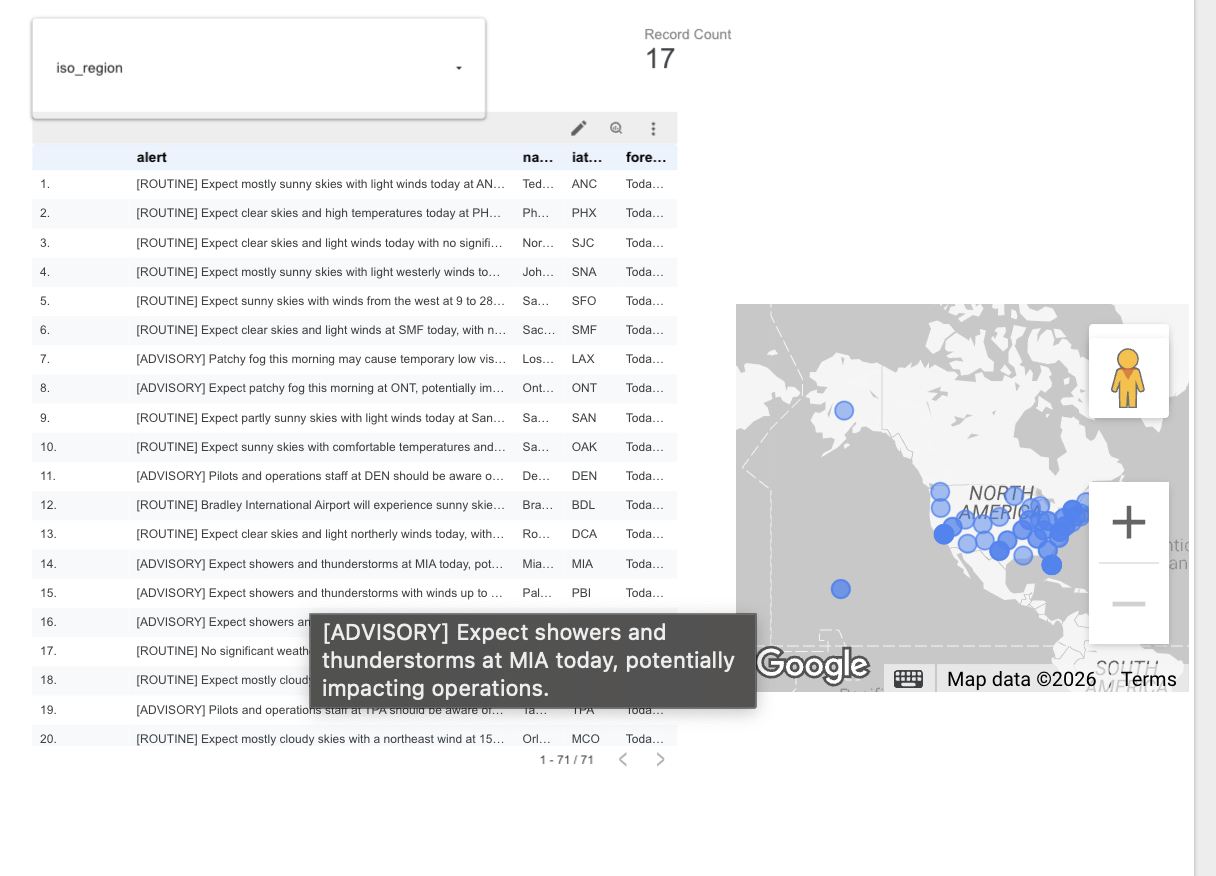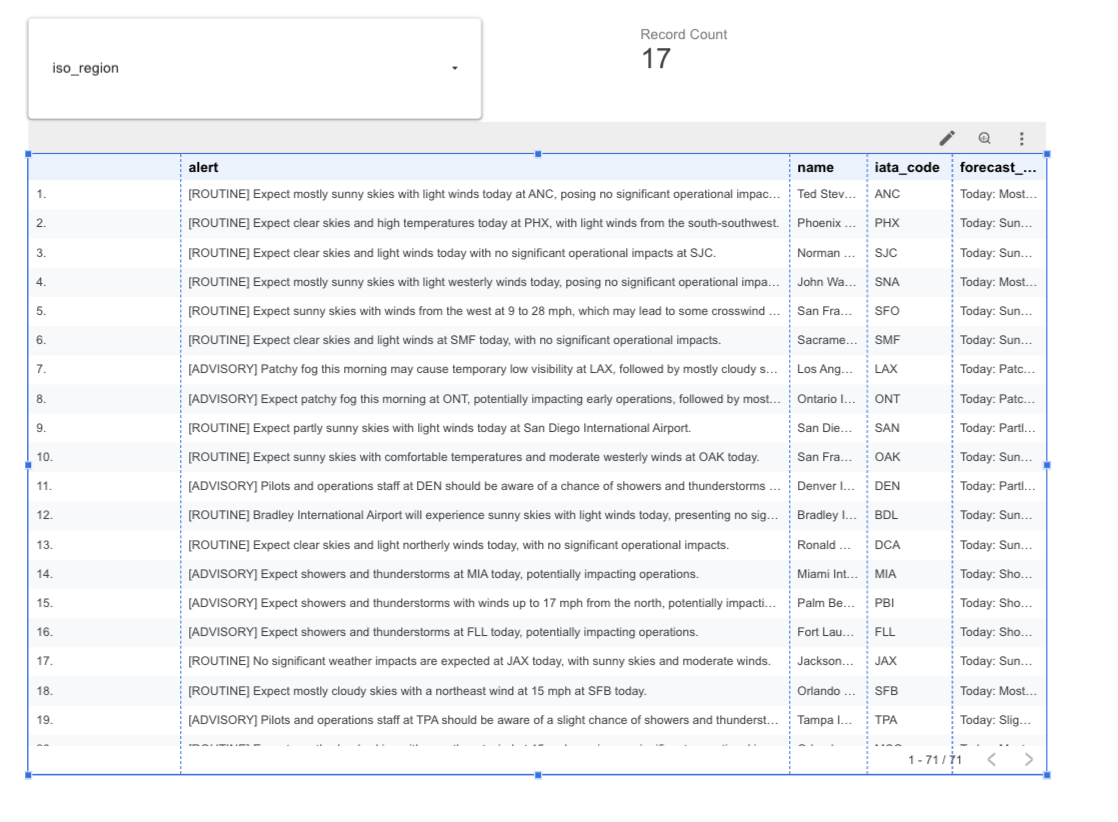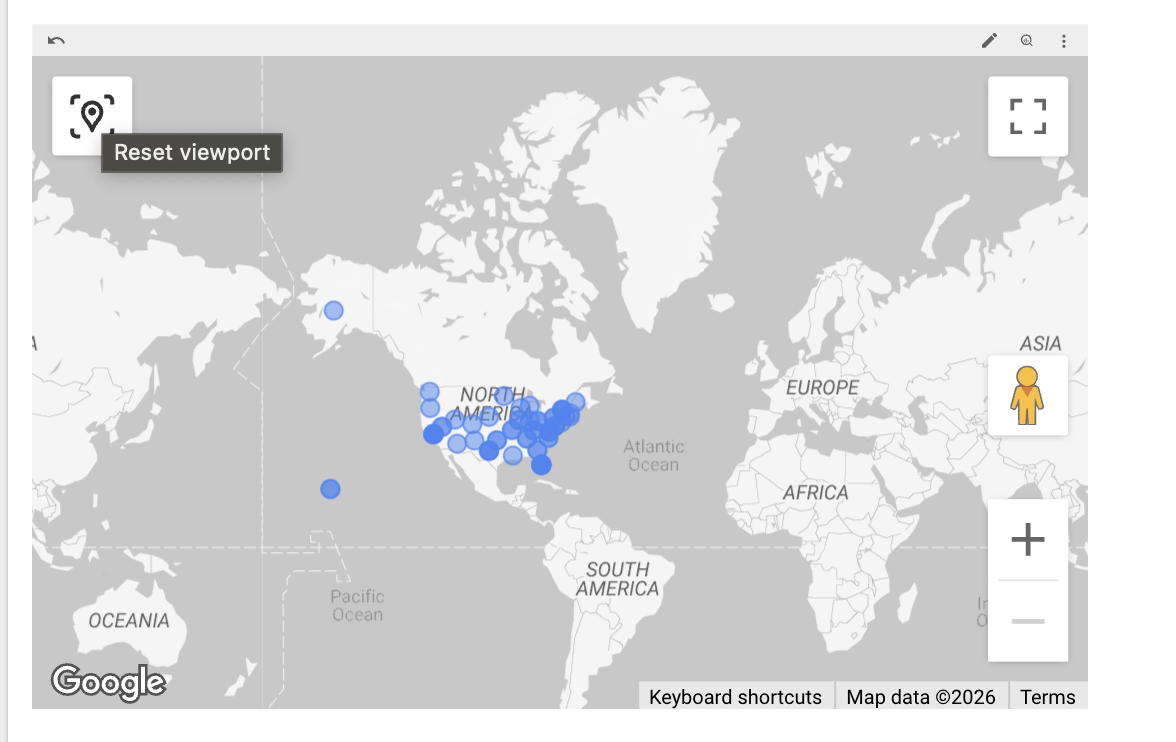